# OULAD - Deep Learning Modeling

This notebook loads the tensor data and trains PyTorch models (LSTM/Transformer).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
RANDOM_SEED = 42

# Cập nhật DATAPATH nếu cần (mặc định lấy từ thư mục seq_data)
DATAPATH = '/kaggle/input/notebooks/lnthuc/oulad-01/'
SEQ_PATH = DATAPATH + 'seq_data/'

try:
    X_seq_train = np.load(SEQ_PATH + 'X_seq_train.npy')
    X_static_train = np.load(SEQ_PATH + 'X_static_train.npy')
    mask_train = np.load(SEQ_PATH + 'mask_train.npy')
    y_train = np.load(SEQ_PATH + 'y_train.npy')
    
    X_seq_test = np.load(SEQ_PATH + 'X_seq_test.npy')
    X_static_test = np.load(SEQ_PATH + 'X_static_test.npy')
    mask_test = np.load(SEQ_PATH + 'mask_test.npy')
    y_test = np.load(SEQ_PATH + 'y_test.npy')
    print("Loaded TENSOR formats successfully.")
    print("X_seq_train shape:", X_seq_train.shape)
except FileNotFoundError:
    print("Data not found! Please run Data Processing notebook first and adjust SEQ_PATH.")


Loaded TENSOR formats successfully.
X_seq_train shape: (21333, 34, 33)


In [2]:
import json

try:
    with open(SEQ_PATH + 'feature_cols_detail.json', 'r') as f:
        meta = json.load(f)
    DYNAMIC_FEATURES = meta['dynamic_features']
    STATIC_FEATURES = meta['static_features']
    print(f"Found {len(DYNAMIC_FEATURES)} dynamic features and {len(STATIC_FEATURES)} static features.")
except:
    print("Could not load feature columns metadata.")
    # Fallback to counts if metadata is missing (based on original array shapes)
    # 33 dynamic, 25 static

# Define T_MAX from sequence length
if 'X_seq_train' in locals():
    T_MAX = X_seq_train.shape[1]


Found 33 dynamic features and 25 static features.


## 5. PyTorch Dataset — Random-Truncation Training

Muc dich **realtime EWS**: model phai predict duoc o **bat ky tuan `t` nao** trong `[t_min, T_MAX-1]`.

**Random-truncation training:** moi sample moi epoch random mot `t` trong `[4, T_MAX-1]`, mask het cac tuan `> t`, predict target. Nhu vay model hoc predict deu o moi tuan.

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

class OULADSeqDataset(Dataset):
    def __init__(self, X_seq, X_static, mask, y, random_trunc=True, t_min=4, fixed_t=None):
        self.X_seq    = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.mask     = torch.from_numpy(mask).bool()
        self.y        = torch.from_numpy(y).float()
        self.T = X_seq.shape[1]
        self.random_trunc = random_trunc
        self.t_min = t_min
        self.fixed_t = fixed_t

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq    = self.X_seq[idx]
        static = self.X_static[idx]
        mask   = self.mask[idx].clone()
        y      = self.y[idx]

        if self.fixed_t is not None:
            t = self.fixed_t
        elif self.random_trunc:
            t = torch.randint(self.t_min, self.T, (1,)).item()
        else:
            t = self.T - 1

        if t < self.T - 1:
            mask[t+1:] = True

        return seq, static, mask, y, t

print('Dataset class ready.')

Device: cuda
Dataset class ready.


## 6. LSTM Model

In [4]:
class EWSLSTM(nn.Module):
    def __init__(self, n_dynamic, n_static, hidden=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_dynamic, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.static_proj = nn.Sequential(
            nn.Linear(n_static, hidden), nn.ReLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_seq, x_static, mask):
        out, _ = self.lstm(x_seq)
        lengths = (~mask).sum(dim=1).clamp(min=1) - 1
        idx = lengths.view(-1, 1, 1).expand(-1, 1, out.size(-1))
        h_last = out.gather(1, idx).squeeze(1)
        s = self.static_proj(x_static)
        logits = self.head(torch.cat([h_last, s], dim=1)).squeeze(-1)
        return logits

model_lstm_check = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES))
print(model_lstm_check)
print(f'Params: {sum(p.numel() for p in model_lstm_check.parameters()):,}')

EWSLSTM(
  (lstm): LSTM(33, 64, num_layers=2, batch_first=True, dropout=0.3)
  (static_proj): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Params: 68,609


## 7. Transformer Model

In [5]:
class EWSTransformer(nn.Module):
    def __init__(self, n_dynamic, n_static, d_model=64, nhead=4, nlayers=2,
                 dropout=0.3, max_len=64):
        super().__init__()
        self.input_proj = nn.Linear(n_dynamic, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.static_proj = nn.Sequential(
            nn.Linear(n_static, d_model), nn.ReLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x_seq, x_static, mask):
        B, T, _ = x_seq.shape
        pos = torch.arange(T, device=x_seq.device).unsqueeze(0).expand(B, T)
        h = self.input_proj(x_seq) + self.pos_emb(pos)
        h = self.encoder(h, src_key_padding_mask=mask)
        lengths = (~mask).sum(dim=1).clamp(min=1) - 1
        idx = lengths.view(-1, 1, 1).expand(-1, 1, h.size(-1))
        h_last = h.gather(1, idx).squeeze(1)
        s = self.static_proj(x_static)
        logits = self.head(torch.cat([h_last, s], dim=1)).squeeze(-1)
        return logits

model_tr_check = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES))
print(model_tr_check)
print(f'Params: {sum(p.numel() for p in model_tr_check.parameters()):,}')

EWSTransformer(
  (input_proj): Linear(in_features=33, out_features=64, bias=True)
  (pos_emb): Embedding(64, 64)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (static_proj): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): Linear(i

## 8. Training Loop + Realtime Evaluation

**Eval:** sau khi train, danh gia model o cac checkpoint tuan co dinh: 4, 8, 12, 16, 20, 24.
Moi tuan `t` -> tao dataset voi `fixed_t=t` -> predict -> metric.
Neu metric tang dan theo `t` thi model dung nghia "realtime EWS": cang nhieu info cang predict tot.

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

def train_model(model, X_seq_tr, X_st_tr, mask_tr, y_tr,
                X_seq_va, X_st_va, mask_va, y_va,
                epochs=25, batch_size=256, lr=1e-3,
                t_min=4, pos_weight=None, verbose=True):
    model = model.to(device)

    train_ds = OULADSeqDataset(X_seq_tr, X_st_tr, mask_tr, y_tr,
                               random_trunc=True, t_min=t_min)
    val_ds   = OULADSeqDataset(X_seq_va, X_st_va, mask_va, y_va,
                               random_trunc=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    if pos_weight is None:
        pos = y_tr.sum()
        neg = len(y_tr) - pos
        pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

    history = []
    best_auc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        n = 0
        for seq, static, mask, y, t in train_loader:
            seq, static, mask, y = seq.to(device), static.to(device), mask.to(device), y.to(device)
            optim.zero_grad()
            logits = model(seq, static, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            tot_loss += loss.item() * len(y)
            n += len(y)
        sched.step()

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for seq, static, mask, y, t in val_loader:
                seq, static, mask = seq.to(device), static.to(device), mask.to(device)
                logits = model(seq, static, mask)
                all_p.append(torch.sigmoid(logits).cpu().numpy())
                all_y.append(y.numpy())
        all_p = np.concatenate(all_p)
        all_y = np.concatenate(all_y)
        auc = roc_auc_score(all_y, all_p)
        f1  = f1_score(all_y, (all_p > 0.5).astype(int))

        history.append({'epoch': epoch, 'train_loss': tot_loss / n, 'val_auc': auc, 'val_f1': f1})
        if verbose:
            print(f'Ep {epoch+1:02d} | loss={tot_loss/n:.4f} | val_auc={auc:.4f} | val_f1={f1:.4f}')

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

print('train_model ready.')

train_model ready.


In [7]:
def eval_at_weeks(model, X_seq, X_static, mask, y, weeks=(4,8,12,16,20,24), batch_size=256):
    """Danh gia model o cac checkpoint tuan co dinh."""
    results = []
    model.eval()
    for t in weeks:
        if t >= X_seq.shape[1]:
            continue
        ds = OULADSeqDataset(X_seq, X_static, mask, y, random_trunc=False, fixed_t=t)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        all_p, all_y = [], []
        with torch.no_grad():
            for seq, static, m, yy, _ in loader:
                seq, static, m = seq.to(device), static.to(device), m.to(device)
                logits = model(seq, static, m)
                all_p.append(torch.sigmoid(logits).cpu().numpy())
                all_y.append(yy.numpy())
        all_p = np.concatenate(all_p); all_y = np.concatenate(all_y)
        pred = (all_p > 0.5).astype(int)
        results.append({
            'week': t,
            'auc':       roc_auc_score(all_y, all_p),
            'accuracy':  accuracy_score(all_y, pred),
            'precision': precision_score(all_y, pred, zero_division=0),
            'recall':    recall_score(all_y, pred, zero_division=0),
            'f1':        f1_score(all_y, pred, zero_division=0),
        })
    return pd.DataFrame(results)

print('eval_at_weeks ready.')

eval_at_weeks ready.


In [8]:
# 8.1 Train LSTM
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_lstm = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                     hidden=64, num_layers=2, dropout=0.3)
model_lstm, hist_lstm = train_model(
    model_lstm, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=1e-3, t_min=4
)

Ep 01 | loss=0.4019 | val_auc=0.9754 | val_f1=0.9279
Ep 02 | loss=0.2907 | val_auc=0.9788 | val_f1=0.9317
Ep 03 | loss=0.2839 | val_auc=0.9796 | val_f1=0.9330
Ep 04 | loss=0.2761 | val_auc=0.9801 | val_f1=0.9345
Ep 05 | loss=0.2731 | val_auc=0.9815 | val_f1=0.9379
Ep 06 | loss=0.2688 | val_auc=0.9816 | val_f1=0.9357
Ep 07 | loss=0.2620 | val_auc=0.9814 | val_f1=0.9365
Ep 08 | loss=0.2655 | val_auc=0.9812 | val_f1=0.9349
Ep 09 | loss=0.2655 | val_auc=0.9816 | val_f1=0.9337
Ep 10 | loss=0.2654 | val_auc=0.9820 | val_f1=0.9374
Ep 11 | loss=0.2617 | val_auc=0.9818 | val_f1=0.9352
Ep 12 | loss=0.2631 | val_auc=0.9818 | val_f1=0.9344
Ep 13 | loss=0.2610 | val_auc=0.9814 | val_f1=0.9328
Ep 14 | loss=0.2636 | val_auc=0.9817 | val_f1=0.9338
Ep 15 | loss=0.2627 | val_auc=0.9821 | val_f1=0.9348
Ep 16 | loss=0.2592 | val_auc=0.9817 | val_f1=0.9352
Ep 17 | loss=0.2543 | val_auc=0.9815 | val_f1=0.9347
Ep 18 | loss=0.2589 | val_auc=0.9816 | val_f1=0.9335
Ep 19 | loss=0.2556 | val_auc=0.9820 | val_f1=

In [9]:
# 8.2 Evaluate LSTM o cac checkpoint tuan
res_lstm = eval_at_weeks(model_lstm, X_seq_test, X_static_test, mask_test, y_test,
                         weeks=(4,8,12,16,20,24))
print('LSTM realtime performance:')
print(res_lstm.round(4))

LSTM realtime performance:
   week     auc  accuracy  precision  recall      f1
0     4  0.8151    0.7251     0.8131  0.6059  0.6944
1     8  0.8772    0.7813     0.8547  0.6934  0.7657
2    12  0.9025    0.8218     0.8555  0.7874  0.8200
3    16  0.9309    0.8573     0.9213  0.7906  0.8510
4    20  0.9474    0.8786     0.9486  0.8082  0.8728
5    24  0.9640    0.9047     0.9599  0.8506  0.9020


In [10]:
# 8.3 Train Transformer
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
model_tr = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                          d_model=64, nhead=4, nlayers=2, dropout=0.3,
                          max_len=T_MAX + 8)
model_tr, hist_tr = train_model(
    model_tr, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=1e-3, t_min=4
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Ep 01 | loss=0.3881 | val_auc=0.9702 | val_f1=0.9132
Ep 02 | loss=0.3078 | val_auc=0.9722 | val_f1=0.9164
Ep 03 | loss=0.2986 | val_auc=0.9725 | val_f1=0.9214
Ep 04 | loss=0.2925 | val_auc=0.9742 | val_f1=0.9250
Ep 05 | loss=0.2914 | val_auc=0.9745 | val_f1=0.9237
Ep 06 | loss=0.2887 | val_auc=0.9760 | val_f1=0.9280
Ep 07 | loss=0.2826 | val_auc=0.9769 | val_f1=0.9263
Ep 08 | loss=0.2839 | val_auc=0.9760 | val_f1=0.9268
Ep 09 | loss=0.2746 | val_auc=0.9770 | val_f1=0.9310
Ep 10 | loss=0.2776 | val_auc=0.9771 | val_f1=0.9307
Ep 11 | loss=0.2746 | val_auc=0.9766 | val_f1=0.9294
Ep 12 | loss=0.2697 | val_auc=0.9769 | val_f1=0.9262
Ep 13 | loss=0.2744 | val_auc=0.9786 | val_f1=0.9324
Ep 14 | loss=0.2687 | val_auc=0.9781 | val_f1=0.9341
Ep 15 | loss=0.2677 | val_auc=0.9791 | val_f1=0.9349
Ep 16 | loss=0.2657 | val_auc=0.9793 | val_f1=0.9334
Ep 17 | loss=0.2676 | val_auc=0.9788 | val_f1=0.9332
Ep 18 | loss=0.2621 | val_auc=0.9789 | val_f1=0.9344
Ep 19 | loss=0.2631 | val_auc=0.9791 | val_f1=

In [11]:
# 8.4 Evaluate Transformer
res_tr = eval_at_weeks(model_tr, X_seq_test, X_static_test, mask_test, y_test,
                       weeks=(4,8,12,16,20,24))
print('Transformer realtime performance:')
print(res_tr.round(4))

Transformer realtime performance:
   week     auc  accuracy  precision  recall      f1
0     4  0.8209    0.7188     0.8252  0.5766  0.6788
1     8  0.8820    0.7951     0.8784  0.6993  0.7787
2    12  0.8986    0.8129     0.8831  0.7341  0.8017
3    16  0.9294    0.8540     0.9240  0.7810  0.8465
4    20  0.9471    0.8792     0.9447  0.8132  0.8741
5    24  0.9628    0.9025     0.9606  0.8454  0.8994


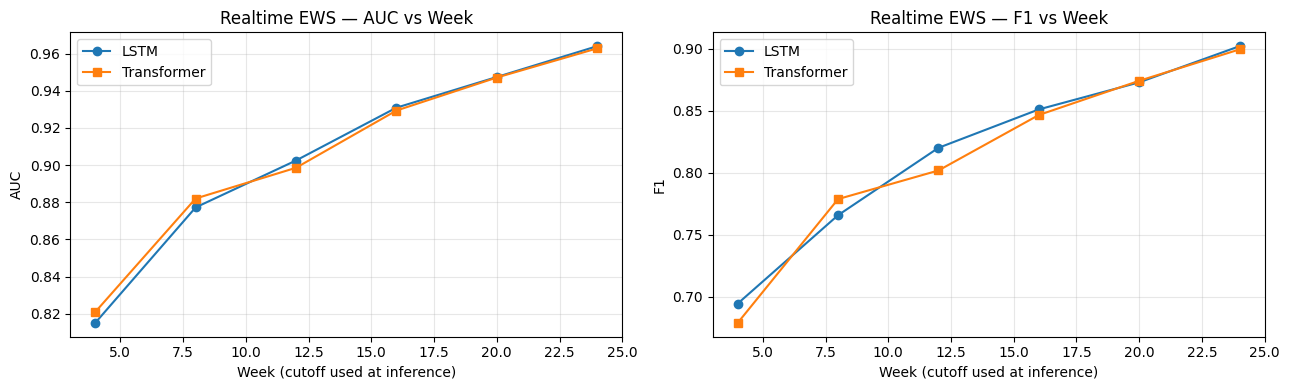

In [12]:
# 8.5 So sanh & ve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for ax, metric in zip(axes, ['auc','f1']):
    ax.plot(res_lstm['week'], res_lstm[metric], 'o-', label='LSTM')
    ax.plot(res_tr['week'],   res_tr[metric],   's-', label='Transformer')
    ax.set_xlabel('Week (cutoff used at inference)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'Realtime EWS — {metric.upper()} vs Week')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Hyperparameter Tuning with Optuna

Trong phần này, chúng ta sử dụng Optuna để dò tìm siêu tham số tối ưu cho mô hình. Mục tiêu là tối đa hoá **F1 Score** (như đề xuất, F1 phản ánh trực tiếp hiệu quả phân loại cuối cùng sau khi áp dụng ngưỡng 0.5, đặc biệt hữu ích khi cần chẩn đoán sớm). 
Chúng ta cũng áp dụng kỹ thuật **Pruning (MedianPruner)** để ngắt sớm các thử nghiệm kém hiệu quả, tiết kiệm tài nguyên trên GPU.

In [13]:
!pip install optuna
import optuna


In [14]:
def train_model_optuna(model, X_seq_tr, X_st_tr, mask_tr, y_tr,
                       X_seq_va, X_st_va, mask_va, y_va,
                       epochs=25, batch_size=256, lr=1e-3,
                       t_min=4, pos_weight=None, verbose=False, trial=None):
    model = model.to(device)

    train_ds = OULADSeqDataset(X_seq_tr, X_st_tr, mask_tr, y_tr,
                               random_trunc=True, t_min=t_min)
    val_ds   = OULADSeqDataset(X_seq_va, X_st_va, mask_va, y_va,
                               random_trunc=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    if pos_weight is None:
        pos = y_tr.sum()
        neg = len(y_tr) - pos
        pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

    best_f1 = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for seq, static, mask, y, t in train_loader:
            seq, static, mask, y = seq.to(device), static.to(device), mask.to(device), y.to(device)
            optim.zero_grad()
            logits = model(seq, static, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
        sched.step()

        model.eval()
        val_f1_list = []
        for check_t in [4, 8, 12, 16, 20, 24]:
            if check_t >= X_seq_va.shape[1]: continue
            val_ds.fixed_t = check_t
            
            all_p, all_y = [], []
            with torch.no_grad():
                for seq, static, mask, y, t in val_loader:
                    seq, static, mask = seq.to(device), static.to(device), mask.to(device)
                    logits = model(seq, static, mask)
                    all_p.append(torch.sigmoid(logits).cpu().numpy())
                    all_y.append(y.numpy())
            all_p = np.concatenate(all_p)
            all_y = np.concatenate(all_y)
            f1_t = f1_score(all_y, (all_p > 0.5).astype(int))
            val_f1_list.append(f1_t)
            
        f1 = np.mean(val_f1_list) # Evaluate average Realtime performance
        
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - val_f1_mean: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Tích hợp Pruning của Optuna
        if trial is not None:
            trial.report(f1, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    if best_state is not None:
        model.load_state_dict(best_state)
        
    return best_f1


In [15]:
def objective_lstm(trial):
    hidden = trial.suggest_categorical("hidden", [32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    model = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                     hidden=hidden, num_layers=num_layers, dropout=dropout)
    
    best_f1 = train_model_optuna(
        model, X_seq_train, X_static_train, mask_train, y_train,
        X_seq_test, X_static_test, mask_test, y_test,
        epochs=25, batch_size=256, lr=lr, t_min=4, trial=trial, verbose=False
    )
    return best_f1


In [16]:
study_lstm = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_lstm.enqueue_trial({"hidden": 64, "num_layers": 2, "dropout": 0.3, "lr": 1e-3})
study_lstm.optimize(objective_lstm, n_trials=50) # Set 50 trials for Kaggle environment
print("Best LSTM parameters:", study_lstm.best_params)
print("Best LSTM F1:", study_lstm.best_value)


[I 2026-05-20 07:48:51,172] A new study created in memory with name: no-name-55d66438-ef91-4d86-ad8f-0282d3fc02e8
[I 2026-05-20 07:50:11,557] Trial 0 finished with value: 0.8209544910078779 and parameters: {'hidden': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}. Best is trial 0 with value: 0.8209544910078779.
[I 2026-05-20 07:51:39,991] Trial 1 finished with value: 0.8196584196949672 and parameters: {'hidden': 128, 'num_layers': 2, 'dropout': 0.2754162404303788, 'lr': 0.00016104884283163492}. Best is trial 0 with value: 0.8209544910078779.
[I 2026-05-20 07:53:03,049] Trial 2 finished with value: 0.8229435134334971 and parameters: {'hidden': 128, 'num_layers': 1, 'dropout': 0.2598005355602362, 'lr': 0.001674714160981702}. Best is trial 2 with value: 0.8229435134334971.
[I 2026-05-20 07:54:26,690] Trial 3 finished with value: 0.826647185323511 and parameters: {'hidden': 128, 'num_layers': 1, 'dropout': 0.22623584419558251, 'lr': 0.006192657684185573}. Best is trial 3 with value: 0.8

Best LSTM parameters: {'hidden': 128, 'num_layers': 1, 'dropout': 0.19452001564946012, 'lr': 0.0058081715522965045}
Best LSTM F1: 0.8305618866343313


In [17]:
def objective_tr(trial):
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nlayers = trial.suggest_int("nlayers", 1, 3)
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    model = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                           d_model=d_model, nhead=nhead, nlayers=nlayers, dropout=dropout,
                           max_len=X_seq_train.shape[1] + 8)
    
    best_f1 = train_model_optuna(
        model, X_seq_train, X_static_train, mask_train, y_train,
        X_seq_test, X_static_test, mask_test, y_test,
        epochs=25, batch_size=256, lr=lr, t_min=4, trial=trial, verbose=False
    )
    return best_f1


In [18]:
study_tr = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_tr.enqueue_trial({"d_model": 64, "nhead": 4, "nlayers": 2, "dropout": 0.3, "lr": 1e-3})
study_tr.optimize(objective_tr, n_trials=50) # Set 50 trials
print("Best Transformer parameters:", study_tr.best_params)
print("Best Transformer F1:", study_tr.best_value)


[I 2026-05-20 08:51:10,767] A new study created in memory with name: no-name-6c63fabf-4d51-4512-b953-75249fbbe1bb
[I 2026-05-20 08:52:54,269] Trial 0 finished with value: 0.8278372135654214 and parameters: {'d_model': 64, 'nlayers': 2, 'nhead': 4, 'dropout': 0.3, 'lr': 0.001}. Best is trial 0 with value: 0.8278372135654214.
[I 2026-05-20 08:55:02,717] Trial 1 finished with value: 0.6295088079038121 and parameters: {'d_model': 128, 'nlayers': 3, 'nhead': 4, 'dropout': 0.27247139368941464, 'lr': 0.007313142716217597}. Best is trial 0 with value: 0.8278372135654214.
[I 2026-05-20 08:56:59,441] Trial 2 finished with value: 0.8199773050812409 and parameters: {'d_model': 64, 'nlayers': 3, 'nhead': 4, 'dropout': 0.2162483666073409, 'lr': 0.0038263314976023526}. Best is trial 0 with value: 0.8278372135654214.
[I 2026-05-20 08:58:27,358] Trial 3 finished with value: 0.8219254750909878 and parameters: {'d_model': 32, 'nlayers': 1, 'nhead': 8, 'dropout': 0.3928608347331568, 'lr': 0.00175594415743

Best Transformer parameters: {'d_model': 128, 'nlayers': 3, 'nhead': 4, 'dropout': 0.17727716434285848, 'lr': 0.0006575666197846281}
Best Transformer F1: 0.8289105092947439


## 10. Huấn luyện lại với Tham Số Tốt Nhất & Lưu Mô Hình

Sau khi Optuna tìm ra bộ tham số tốt nhất, chúng ta sẽ tự động sử dụng bộ tham số đó để khởi tạo và huấn luyện mô hình một lần nữa. Sau đó, mô hình sẽ được lưu xuống ổ đĩa (định dạng `.pth` chuẩn của PyTorch) để có thể tái sử dụng (Inference) mà không cần train lại.

In [19]:
# 10.1 Retrain LSTM với Best Params
print("Retraining LSTM with Best Params...")
best_lstm_params = study_lstm.best_params
best_lstm_model = EWSLSTM(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                          hidden=best_lstm_params['hidden'], 
                          num_layers=best_lstm_params['num_layers'], 
                          dropout=best_lstm_params['dropout'])

# Lưu ý: Không truyền `trial` vào đây vì chúng ta muốn train hết số epoch
best_f1_lstm = train_model_optuna(
    best_lstm_model, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=best_lstm_params['lr'], t_min=4, verbose=True
)

Retraining LSTM with Best Params...
Epoch 1/25 - val_f1_mean: 0.8168
Epoch 2/25 - val_f1_mean: 0.8051
Epoch 3/25 - val_f1_mean: 0.8241
Epoch 4/25 - val_f1_mean: 0.8191
Epoch 5/25 - val_f1_mean: 0.8217
Epoch 6/25 - val_f1_mean: 0.8195
Epoch 7/25 - val_f1_mean: 0.8128
Epoch 8/25 - val_f1_mean: 0.8166
Epoch 9/25 - val_f1_mean: 0.8099
Epoch 10/25 - val_f1_mean: 0.8120
Epoch 11/25 - val_f1_mean: 0.8106
Epoch 12/25 - val_f1_mean: 0.8184
Epoch 13/25 - val_f1_mean: 0.8003
Epoch 14/25 - val_f1_mean: 0.8137
Epoch 15/25 - val_f1_mean: 0.8135
Epoch 16/25 - val_f1_mean: 0.8140
Epoch 17/25 - val_f1_mean: 0.8100
Epoch 18/25 - val_f1_mean: 0.8053
Epoch 19/25 - val_f1_mean: 0.8117
Epoch 20/25 - val_f1_mean: 0.8098
Epoch 21/25 - val_f1_mean: 0.8121
Epoch 22/25 - val_f1_mean: 0.8078
Epoch 23/25 - val_f1_mean: 0.8075
Epoch 24/25 - val_f1_mean: 0.8088
Epoch 25/25 - val_f1_mean: 0.8089


In [20]:
max_weeks = X_seq_test.shape[1] 

res_lstm_best = eval_at_weeks(
    best_lstm_model, 
    X_seq_test, 
    X_static_test, 
    mask_test, 
    y_test,
    weeks=list(range(max_weeks))
)

print('LSTM realtime performance (All weeks):')
print(res_lstm_best.round(4))

LSTM realtime performance (All weeks):
    week     auc  accuracy  precision  recall      f1
0      0  0.7128    0.6366     0.6077  0.8322  0.7024
1      1  0.7295    0.6639     0.6596  0.7189  0.6880
2      2  0.7625    0.6892     0.7186  0.6522  0.6838
3      3  0.7929    0.7150     0.7609  0.6519  0.7022
4      4  0.8197    0.7369     0.7945  0.6603  0.7212
5      5  0.8334    0.7465     0.8121  0.6612  0.7289
6      6  0.8475    0.7552     0.8230  0.6690  0.7380
7      7  0.8662    0.7727     0.8425  0.6876  0.7572
8      8  0.8773    0.7917     0.8626  0.7086  0.7781
9      9  0.8848    0.8006     0.8653  0.7262  0.7897
10    10  0.8874    0.8053     0.8363  0.7737  0.8038
11    11  0.8886    0.7986     0.8086  0.7980  0.8033
12    12  0.8980    0.8124     0.8300  0.7999  0.8147
13    13  0.9082    0.8279     0.8657  0.7884  0.8252
14    14  0.9144    0.8354     0.8801  0.7880  0.8315
15    15  0.9258    0.8512     0.9146  0.7844  0.8445
16    16  0.9314    0.8589     0.9204  0.79

In [21]:
# Lưu mô hình
import os
import json
os.makedirs('/kaggle/working/models', exist_ok=True)
torch.save(best_lstm_model.state_dict(), '/kaggle/working/models/best_lstm_model.pth')
with open('/kaggle/working/models/best_lstm_params.json', 'w') as f:
    json.dump(best_lstm_params, f, indent=2)
print("\nĐã lưu LSTM model vào /kaggle/working/models/best_lstm_model.pth")


Đã lưu LSTM model vào /kaggle/working/models/best_lstm_model.pth


In [22]:
# 10.2 Retrain Transformer với Best Params
print("Retraining Transformer with Best Params...")
best_tr_params = study_tr.best_params
best_tr_model = EWSTransformer(len(DYNAMIC_FEATURES), len(STATIC_FEATURES),
                               d_model=best_tr_params['d_model'], 
                               nhead=best_tr_params['nhead'], 
                               nlayers=best_tr_params['nlayers'], 
                               dropout=best_tr_params['dropout'],
                               max_len=X_seq_train.shape[1] + 8)

best_f1_tr = train_model_optuna(
    best_tr_model, X_seq_train, X_static_train, mask_train, y_train,
    X_seq_test, X_static_test, mask_test, y_test,
    epochs=25, batch_size=256, lr=best_tr_params['lr'], t_min=4, verbose=True
)


Retraining Transformer with Best Params...
Epoch 1/25 - val_f1_mean: 0.7936
Epoch 2/25 - val_f1_mean: 0.8154
Epoch 3/25 - val_f1_mean: 0.8208
Epoch 4/25 - val_f1_mean: 0.8222
Epoch 5/25 - val_f1_mean: 0.8180
Epoch 6/25 - val_f1_mean: 0.8219
Epoch 7/25 - val_f1_mean: 0.8082
Epoch 8/25 - val_f1_mean: 0.8187
Epoch 9/25 - val_f1_mean: 0.8231
Epoch 10/25 - val_f1_mean: 0.8228
Epoch 11/25 - val_f1_mean: 0.8025
Epoch 12/25 - val_f1_mean: 0.7993
Epoch 13/25 - val_f1_mean: 0.8118
Epoch 14/25 - val_f1_mean: 0.8113
Epoch 15/25 - val_f1_mean: 0.8163
Epoch 16/25 - val_f1_mean: 0.8004
Epoch 17/25 - val_f1_mean: 0.8063
Epoch 18/25 - val_f1_mean: 0.8132
Epoch 19/25 - val_f1_mean: 0.8135
Epoch 20/25 - val_f1_mean: 0.8129
Epoch 21/25 - val_f1_mean: 0.8147
Epoch 22/25 - val_f1_mean: 0.8134
Epoch 23/25 - val_f1_mean: 0.8143
Epoch 24/25 - val_f1_mean: 0.8135
Epoch 25/25 - val_f1_mean: 0.8139


In [23]:
max_weeks = X_seq_test.shape[1] 

res_tr_best = eval_at_weeks(
    best_tr_model, 
    X_seq_test, 
    X_static_test, 
    mask_test, 
    y_test,
    weeks=list(range(max_weeks))
)

print('TRANSFORMER realtime performance (All weeks):')
print(res_tr_best.round(4))

TRANSFORMER realtime performance (All weeks):
    week     auc  accuracy  precision  recall      f1
0      0  0.7141    0.5770     0.5523  0.9466  0.6976
1      1  0.7225    0.5579     0.5398  0.9642  0.6921
2      2  0.7610    0.6547     0.6251  0.8244  0.7111
3      3  0.7872    0.6835     0.8229  0.4916  0.6155
4      4  0.8251    0.7392     0.7676  0.7084  0.7368
5      5  0.8340    0.7433     0.8209  0.6421  0.7206
6      6  0.8457    0.7440     0.8391  0.6226  0.7148
7      7  0.8609    0.7600     0.8552  0.6433  0.7343
8      8  0.8748    0.7866     0.8489  0.7127  0.7749
9      9  0.8856    0.7995     0.8522  0.7391  0.7916
10    10  0.8871    0.7980     0.8586  0.7281  0.7880
11    11  0.8908    0.8000     0.8223  0.7806  0.8009
12    12  0.8949    0.8099     0.8575  0.7568  0.8040
13    13  0.9055    0.8206     0.8778  0.7574  0.8131
14    14  0.9107    0.8242     0.8430  0.8098  0.8261
15    15  0.9211    0.8420     0.8951  0.7855  0.8367
16    16  0.9264    0.8519     0.891

In [24]:
# Lưu mô hình
torch.save(best_tr_model.state_dict(), '/kaggle/working/models/best_transformer_model.pth')
with open('/kaggle/working/models/best_transformer_params.json', 'w') as f:
    json.dump(best_tr_params, f, indent=2)
print("\nĐã lưu Transformer model vào /kaggle/working/models/best_transformer_model.pth")


Đã lưu Transformer model vào /kaggle/working/models/best_transformer_model.pth
